# Imports

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


# Load Dataset

In [80]:
Data_path=r"C:\Users\ASUS\OneDrive\Documents\ML Project\Smartwatches project\Dataset\smartwatches.csv"

df=pd.read_csv(Data_path)

In [81]:
df.head()

,Unnamed: 0,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
0,0,noise,82990.0,89900.0,7.686318,4.0,65.0,Wrb-sw-colorfitpro4alpha-std-rgld_pnk,NaN,NaN,NaN,NaN,8.0,Yes,NaN,35 - 50 g
1,1,fire-boltt,3799.0,16999.0,77.651627,4.3,20788.0,BSW046,NaN,NaN,Silicon,Yes,3.5,Yes,1.8 inches,50 - 75 g
2,2,boat,1999.0,7990.0,74.981227,3.8,21724.0,Wave Call,NaN,NaN,Silicon,Yes,8.0,Yes,1.7 inches,35 - 50 g
3,3,fire-boltt,1799.0,19999.0,91.004550,4.3,13244.0,BSW053,NaN,NaN,Silicon,Yes,3.5,Yes,1.8 inches,75g +
4,4,noise,1599.0,4999.0,68.013603,4.1,13901.0,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,NaN,NaN,Other,Yes,8.0,Yes,1.7 inches,35 - 50 g


In [82]:
df.columns

Index(['Unnamed: 0', 'Brand', 'Current Price', 'Original Price',
       'Discount Percentage', 'Rating', 'Number OF Ratings', 'Model Name',
       'Dial Shape', 'Strap Color', 'Strap Material', 'Touchscreen',
       'Battery Life (Days)', 'Bluetooth', 'Display Size', 'Weight'],
      dtype='object')

In [83]:
df.shape

(450, 16)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           450 non-null    int64  
 1   Brand                450 non-null    object 
 2   Current Price        440 non-null    float64
 3   Original Price       377 non-null    float64
 4   Discount Percentage  377 non-null    float64
 5   Rating               444 non-null    float64
 6   Number OF Ratings    391 non-null    float64
 7   Model Name           415 non-null    object 
 8   Dial Shape           327 non-null    object 
 9   Strap Color          327 non-null    object 
 10  Strap Material       381 non-null    object 
 11  Touchscreen          413 non-null    object 
 12  Battery Life (Days)  418 non-null    float64
 13  Bluetooth            444 non-null    object 
 14  Display Size         420 non-null    object 
 15  Weight               264 non-null    obj

In [85]:
df.isnull().sum().sort_values(ascending=False)

Weight                 186
Dial Shape             123
Strap Color            123
Original Price          73
Discount Percentage     73
Strap Material          69
Number OF Ratings       59
Touchscreen             37
Model Name              35
Battery Life (Days)     32
Display Size            30
Current Price           10
Rating                   6
Bluetooth                6
Brand                    0
Unnamed: 0               0
dtype: int64

In [86]:
df.describe()

,Unnamed: 0,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Battery Life (Days)
count,450.000000,440.000000,377.000000,377.000000,444.000000,391.000000,418.000000
mean,224.500000,12747.554545,14598.204244,48.236894,4.031306,11594.726343,14.077392
std,130.048068,17760.666099,15450.028869,24.109830,0.550548,40423.889227,7.718503
min,0.000000,1199.000000,1669.000000,-79.688436,1.000000,1.000000,0.750000
25%,112.250000,2180.750000,5999.000000,33.337037,3.900000,68.500000,8.000000
50%,224.500000,3999.000000,7999.000000,54.550414,4.100000,996.000000,17.500000
75%,336.750000,17121.750000,17999.000000,66.677780,4.300000,6022.000000,22.000000
max,449.000000,139990.000000,96390.000000,91.004550,5.000000,619130.000000,22.000000


# Data Cleaning 

### Drop Column/Feature

In [87]:
df.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)
df.shape

(450, 15)

# Prices: 

## Current Price:

<Axes: xlabel='Current Price', ylabel='Count'>

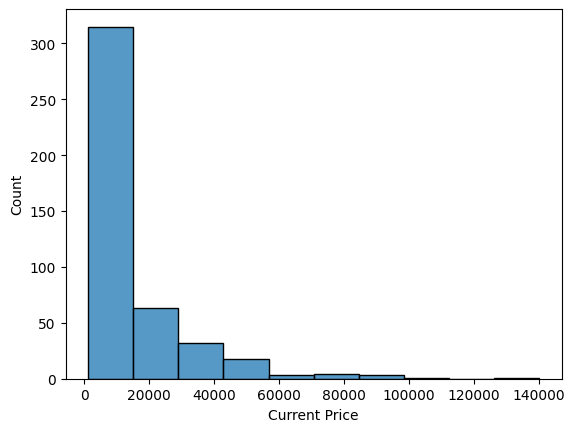

In [88]:
sns.histplot(data=df, x="Current Price", bins=10)

<Axes: xlabel='Current Price'>

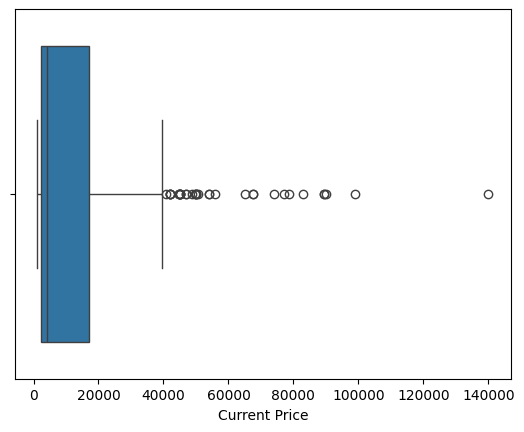

In [89]:
sns.boxplot(data=df, x=df["Current Price"])

In [90]:
df["Current Price"].skew()

np.float64(2.7243756109561494)

#### After analysing the 'Current Price' using Boxplot, Histogram, and Skew, it is highly reight skewed. So, we will use Median to fill the NULL Values

In [91]:
df["Current Price"].fillna(df["Current Price"].median(), inplace=True)

In [92]:
df.isnull().sum()

Brand                    0
Current Price            0
Original Price          73
Discount Percentage     73
Rating                   6
Number OF Ratings       59
Model Name              35
Dial Shape             123
Strap Color            123
Strap Material          69
Touchscreen             37
Battery Life (Days)     32
Bluetooth                6
Display Size            30
Weight                 186
dtype: int64

## Original Price:

<Axes: xlabel='Original Price', ylabel='Count'>

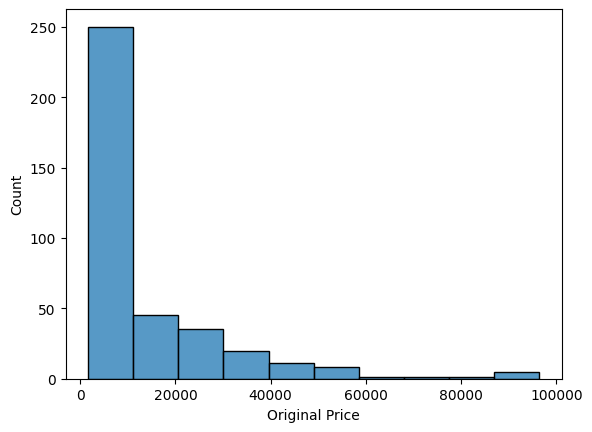

In [93]:
sns.histplot(data=df, x="Original Price", bins=10)

<Axes: xlabel='Original Price'>

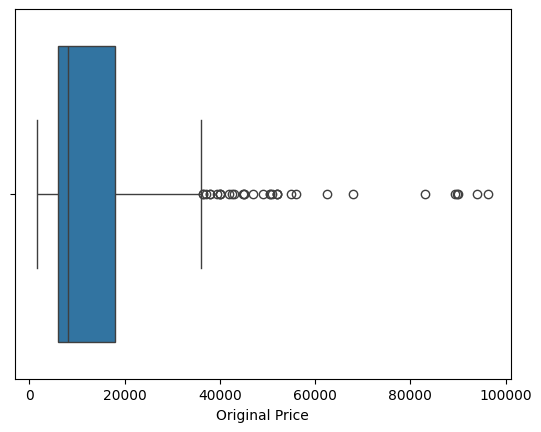

In [94]:
sns.boxplot(data=df, x=df["Original Price"])

In [95]:
df["Original Price"].skew()

np.float64(2.668311152241214)

#### After analysing the 'Original Price' using Boxplot, Histogram, and Skew, it is Highly Right Skewed. So, we will use Median to fill the NULL Values

In [96]:
df["Original Price"].fillna(df["Original Price"].median(), inplace=True)

## Discount Percentage:

In [97]:
df.describe()

,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Battery Life (Days)
count,450.000000,450.000000,377.000000,444.000000,391.000000,418.000000
mean,12553.142222,13527.666667,48.236894,4.031306,11594.726343,14.077392
std,17609.161734,14346.636604,24.109830,0.550548,40423.889227,7.718503
min,1199.000000,1669.000000,-79.688436,1.000000,1.000000,0.750000
25%,2199.000000,5999.000000,33.337037,3.900000,68.500000,8.000000
50%,3999.000000,7999.000000,54.550414,4.100000,996.000000,17.500000
75%,16999.000000,13749.000000,66.677780,4.300000,6022.000000,22.000000
max,139990.000000,96390.000000,91.004550,5.000000,619130.000000,22.000000


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                450 non-null    object 
 1   Current Price        450 non-null    float64
 2   Original Price       450 non-null    float64
 3   Discount Percentage  377 non-null    float64
 4   Rating               444 non-null    float64
 5   Number OF Ratings    391 non-null    float64
 6   Model Name           415 non-null    object 
 7   Dial Shape           327 non-null    object 
 8   Strap Color          327 non-null    object 
 9   Strap Material       381 non-null    object 
 10  Touchscreen          413 non-null    object 
 11  Battery Life (Days)  418 non-null    float64
 12  Bluetooth            444 non-null    object 
 13  Display Size         420 non-null    object 
 14  Weight               264 non-null    object 
dtypes: float64(6), object(9)
memory usage: 5

In [99]:
df["Discount Percentage"].skew()

np.float64(-0.9441234550677982)

<Axes: xlabel='Discount Percentage'>

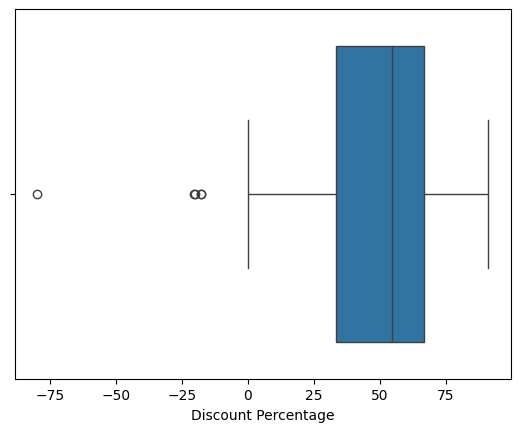

In [100]:
sns.boxplot(x=df["Discount Percentage"])

In [101]:
df["Discount Percentage"].nunique()

271

In [102]:
df["Discount Percentage"].dtype

dtype('float64')

In [103]:
df.isnull().sum()

Brand                    0
Current Price            0
Original Price           0
Discount Percentage     73
Rating                   6
Number OF Ratings       59
Model Name              35
Dial Shape             123
Strap Color            123
Strap Material          69
Touchscreen             37
Battery Life (Days)     32
Bluetooth                6
Display Size            30
Weight                 186
dtype: int64

In [104]:
df[df["Discount Percentage"].isnull()][["Original Price", "Current Price", "Discount Percentage"]].head(10)

,Original Price,Current Price,Discount Percentage
49,7999.0,3999.0,NaN
54,7999.0,3999.0,NaN
56,7999.0,3999.0,NaN
58,7999.0,3999.0,NaN
69,7999.0,3999.0,NaN
71,7999.0,3999.0,NaN
92,7999.0,3999.0,NaN
107,7999.0,3999.0,NaN
123,7999.0,37900.0,NaN
125,7999.0,33900.0,NaN


### Using 'Current Price', 'Original Price'we can calculate the Discount Percentage.

### Formula: ((Original Price - Current Price)/ Original Price )*100

In [105]:
mask = df["Discount Percentage"].isna()

df.loc[mask, "Discount Percentage"] = ((df.loc[mask, "Original Price"] - df.loc[mask, "Current Price"])
                                       / df.loc[mask, "Original Price"]) * 100

## Number of Ratings: 

In [106]:
df["Number OF Ratings"].skew()

np.float64(10.220186267303072)

{'whiskers': [<matplotlib.lines.Line2D at 0x2375764b8c0>,
 'caps': [<matplotlib.lines.Line2D at 0x2375764bb60>,
 'boxes': [<matplotlib.lines.Line2D at 0x2375764b770>],
 'medians': [<matplotlib.lines.Line2D at 0x2375764be00>],
 'fliers': [<matplotlib.lines.Line2D at 0x237576cc050>],
 'means': []}

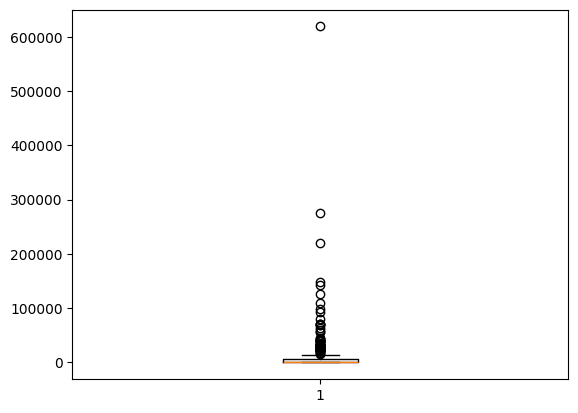

In [107]:
plt.boxplot(x=df["Number OF Ratings"].dropna())

(array([375.,  10.,   3.,   1.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([1.000000e+00, 6.191390e+04, 1.238268e+05, 1.857397e+05,
        2.476526e+05, 3.095655e+05, 3.714784e+05, 4.333913e+05,
        4.953042e+05, 5.572171e+05, 6.191300e+05]),
 <BarContainer object of 10 artists>)

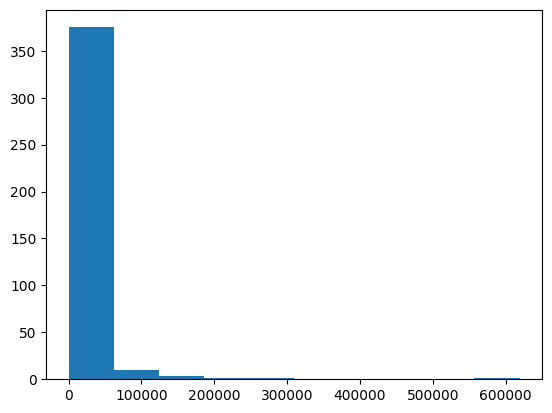

In [108]:
plt.hist(df["Number OF Ratings"], bins=10)

#### 'Number of Rating' is Highly rRight Skewed. So, Median is the right function to fill NULL Values

In [109]:
df["Number OF Ratings"].fillna(df["Number OF Ratings"].median(), inplace=True)

## Touchscreen:


In [110]:
df["Touchscreen"].value_counts()

Touchscreen
Yes    389
No      24
Name: count, dtype: int64

#### As Touchscreen is the categorical column. So, filling NULL values with MODE

In [111]:
df["Touchscreen"].fillna(df["Touchscreen"].mode()[0], inplace=True)

In [112]:
df["Touchscreen"]=df["Touchscreen"].map({"Yes":1, "No":0})

## Bluetooth:

In [113]:
df["Bluetooth"].value_counts()

Bluetooth
Yes    440
No       4
Name: count, dtype: int64

#### Filling NULL Values with mode as 'Bluetooth' is categorical column

In [114]:
df["Bluetooth"].fillna(df["Bluetooth"].mode()[0], inplace=True)

In [115]:
df["Bluetooth"]=df["Bluetooth"].map({"Yes":1, "No":0})

In [116]:
df["Bluetooth"].dtype

dtype('int64')

## Display Size: 

In [117]:
df["Display Size"].value_counts().sort_index(ascending=True)

Display Size
0.0 inches      1
0.1 inches     36
0.2 inches      7
0.5 inches      1
0.6 inches      1
0.8 inches      2
0.9 inches      6
1.0 inches      4
1.1 inches      7
1.2 inches     20
1.3 inches     64
1.4 inches     43
1.5 inches      7
1.6 inches     28
1.7 inches     68
1.8 inches     60
1.9 inches     26
15.9 inches     1
18.5 inches     1
2.0 inches      2
2.1 inches      1
2.3 inches      1
2.4 inches      1
2.7 inches      2
20.0 inches     2
27.9 inches     1
3.0 inches      1
3.3 inches      2
3.5 inches      2
30.0 inches     1
33.0 inches     1
35.9 inches     2
4.0 inches      1
4.2 inches      1
4.3 inches      6
4.4 inches      5
4.5 inches      2
4.6 inches      1
45.0 inches     1
6.9 inches      1
Name: count, dtype: int64

(1.4, 8.0)

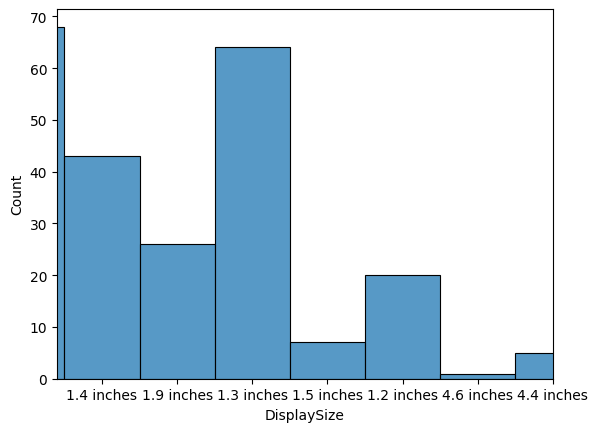

In [118]:
sns.histplot(df["Display Size"],bins=15)
plt.xlabel("DisplaySize")
plt.ylabel("Count")
plt.xlim([1.4, 8])

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                450 non-null    object 
 1   Current Price        450 non-null    float64
 2   Original Price       450 non-null    float64
 3   Discount Percentage  450 non-null    float64
 4   Rating               444 non-null    float64
 5   Number OF Ratings    450 non-null    float64
 6   Model Name           415 non-null    object 
 7   Dial Shape           327 non-null    object 
 8   Strap Color          327 non-null    object 
 9   Strap Material       381 non-null    object 
 10  Touchscreen          450 non-null    int64  
 11  Battery Life (Days)  418 non-null    float64
 12  Bluetooth            450 non-null    int64  
 13  Display Size         420 non-null    object 
 14  Weight               264 non-null    object 
dtypes: float64(6), int64(2), object(7)
memor

In [120]:
# Extracting float values from the column "Display Size", removing inches

def extract_display_size(size):

    extract_float_values=re.findall(r"[+-]?\d+\.\d+", str(size))
   
    if len(extract_float_values)>0:
        return extract_float_values[0]
    
    else:
        return size
    

df["Display Size"]=df["Display Size"].apply(lambda x: extract_display_size(x))

In [121]:
# Again changing the datatype of the 'Display Size' to 'float64'
df["Display Size"]=df["Display Size"].astype("float64")

(0.0, 3.0)

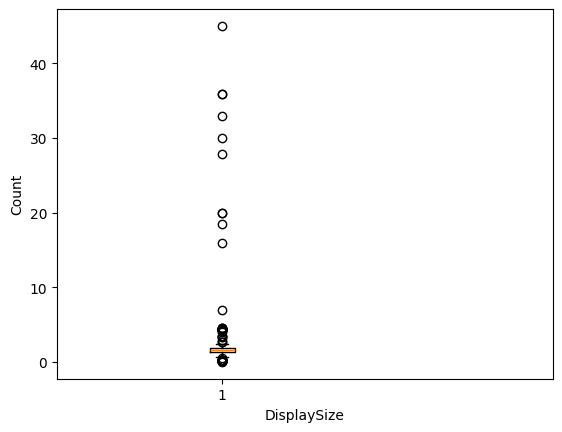

In [122]:

plt.boxplot(x=df["Display Size"].dropna())

plt.xlabel("DisplaySize")
plt.ylabel("Count")
plt.xlim(df["Display Size"].min(), 3)

In [123]:
df["Display Size"].skew()

np.float64(6.878782063381326)

#### Display Size cannot be greater than 3 inches, it is impossible to have display zise >3. so whereever the display size is greater than 3 that value will be changed to "nan" 

In [124]:
df.loc[df["Display Size"]>3,["Display Size"]]=np.nan

#### "Display Size" is Highly Right Skewed. So, we will use median to fill NULL values

In [125]:
df["Display Size"]=df["Display Size"].fillna(df["Display Size"].median())
df.drop(df[df["Display Size"] == 0].index, inplace=True)

## Model Name:

In [126]:
df["Model Name"].nunique()

388

#### As every company has its own model name of their product. it is a high cardinality column, every value is unique. so it won't be a good idea to fill NULL Values with mode. so we will fill NULL values with "Unknown"

In [127]:
df["Model Name"].fillna("Unknown", inplace=True)

## Dial Shape:

In [128]:
df["Dial Shape"].unique()

array([nan, 'Rectangle', 'Square', 'Circle', 'Curved', 'Contemporary',
       'Oval'], dtype=object)

In [129]:
df["Dial Shape"].value_counts()

Dial Shape
Circle          130
Square          101
Rectangle        87
Curved            6
Contemporary      1
Oval              1
Name: count, dtype: int64

In [130]:
df["Dial Shape"].fillna("Missing", inplace=True)

## Strap colour:

In [131]:
df["Strap Color"].nunique()

30

In [132]:
df["Strap Color"].unique()

array([nan, 'Midnight', 'Starlight Sport', 'Black', 'Pink',
       'Orange Alpine', 'Green', 'Gold', 'Blue', 'Silver', 'White',
       'Grey', 'Red', 'Purple', 'Brown', 'Graphite', 'Beige',
       'Morning Glow', 'Passion Pink', 'Beet Juice', 'Charcoal',
       'White Platinum', 'Multicolor', 'Misty Rose', 'Orange', 'Burgundy',
       'Maroon', 'Pink, Gold', 'Deep Wine', 'Sea Green', 'Rose Gold'],
      dtype=object)

In [133]:
df["Strap Color"].value_counts()

Strap Color
Black              132
Blue                41
Grey                34
Silver              14
Pink                14
Green               13
Red                 11
Brown               10
White               10
Gold                 8
Beige                4
Starlight Sport      3
Graphite             3
Purple               3
Rose Gold            3
Orange               3
Midnight             2
Orange Alpine        2
Burgundy             2
Maroon               2
Multicolor           2
Charcoal             2
White Platinum       1
Beet Juice           1
Morning Glow         1
Passion Pink         1
Misty Rose           1
Pink, Gold           1
Deep Wine            1
Sea Green            1
Name: count, dtype: int64

#### Hence it is a categorical column also have low cardinatlity. So, we can fill the values with mode

In [134]:
df["Strap Color"].fillna("Missing", inplace=True)

## Starp material:

In [135]:
df["Strap Material"].value_counts()

Strap Material
Silicon                        247
Rubber                          32
Other                           21
Stainless Steel                 19
Leather                         17
Fluoroelastomer                 13
Aluminium                       11
Thermo Plastic Polyurethene      8
Fabric                           3
Metal                            2
Plastic                          2
Synthetic                        2
Polycarbonate                    1
Carbon-Fiber;                    1
Nylon                            1
Name: count, dtype: int64

#### Hence it is a categorical column also have low cardinatlity. So, we can fill the values with mode

In [136]:
df["Strap Material"].fillna("Missing", inplace=True)

## Battery Life (Days):

In [137]:
df["Battery Life (Days)"].value_counts()

Battery Life (Days)
22.00    176
8.00     106
3.50      73
17.50     42
12.50     12
3.60       6
0.75       3
Name: count, dtype: int64

In [138]:
df["Battery Life (Days)"].dtype

dtype('float64')

In [139]:
df["Battery Life (Days)"].skew()

np.float64(-0.1835448101409323)

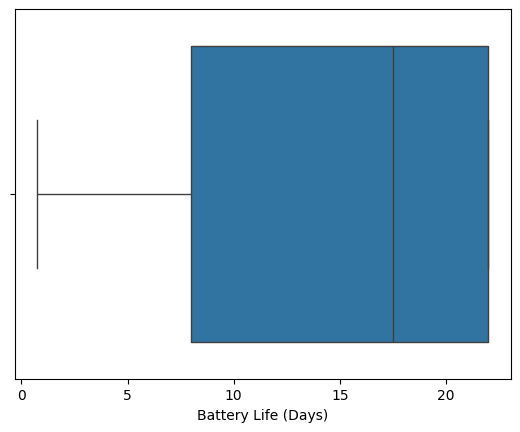

In [140]:
sns.boxplot(x=df["Battery Life (Days)"])
plt.show()

#### As "Battery Life (Days)" is slightly left skewed. So we can fill NULL values with Mean

In [141]:
df["Battery Life (Days)"].fillna(df["Battery Life (Days)"].mean(), inplace=True)

In [142]:
df.isnull().sum()

Brand                    0
Current Price            0
Original Price           0
Discount Percentage      0
Rating                   6
Number OF Ratings        0
Model Name               0
Dial Shape               0
Strap Color              0
Strap Material           0
Touchscreen              0
Battery Life (Days)      0
Bluetooth                0
Display Size             0
Weight                 185
dtype: int64

## Weight:

In [143]:
df["Weight"].describe()

count           264
unique            5
top       20 - 35 g
freq             80
Name: Weight, dtype: object

In [144]:
df["Weight"].unique()

array(['35 - 50 g', '50 - 75 g', '75g +', '20 - 35 g', '<= 20 g', nan],
      dtype=object)

In [145]:
df["Weight"] = df["Weight"].fillna(df["Weight"].mode()[0])

In [146]:
df.isnull().sum()

Brand                  0
Current Price          0
Original Price         0
Discount Percentage    0
Rating                 6
Number OF Ratings      0
Model Name             0
Dial Shape             0
Strap Color            0
Strap Material         0
Touchscreen            0
Battery Life (Days)    0
Bluetooth              0
Display Size           0
Weight                 0
dtype: int64

## filling columns "Rating" with mean value


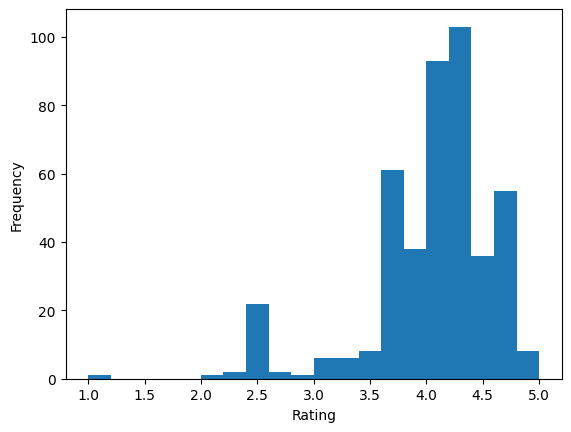

In [147]:

plt.hist(df["Rating"], bins=20)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='Rating'>

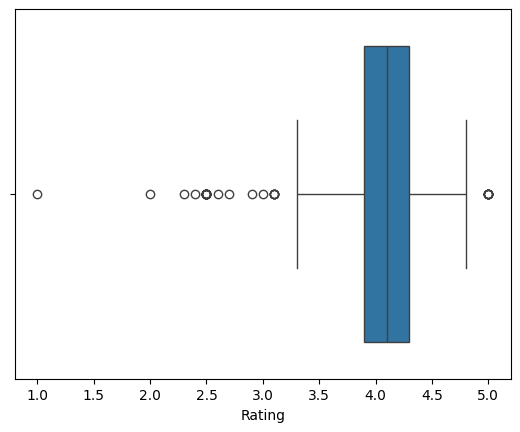

In [148]:
sns.boxplot(x=df["Rating"])

In [149]:
df["Rating"].fillna(df["Rating"].median(), inplace=True)

In [150]:
df.isnull().sum()

Brand                  0
Current Price          0
Original Price         0
Discount Percentage    0
Rating                 0
Number OF Ratings      0
Model Name             0
Dial Shape             0
Strap Color            0
Strap Material         0
Touchscreen            0
Battery Life (Days)    0
Bluetooth              0
Display Size           0
Weight                 0
dtype: int64

In [151]:
df.dtypes

Brand                   object
Current Price          float64
Original Price         float64
Discount Percentage    float64
Rating                 float64
Number OF Ratings      float64
Model Name              object
Dial Shape              object
Strap Color             object
Strap Material          object
Touchscreen              int64
Battery Life (Days)    float64
Bluetooth                int64
Display Size           float64
Weight                  object
dtype: object

## Drop duplicates — last, now that every column is in final form

In [152]:
df.duplicated().sum()

np.int64(10)

In [153]:
df= df.drop_duplicates(
    subset=['Brand', 'Model Name', 'Current Price', 'Rating',
            'Number OF Ratings', 'Strap Color']
).reset_index(drop=True)

In [154]:
#Flag placeholder Rating (2.5) -- do NOT drop here, exclude at model-training time
df['rating_placeholder_flag'] = df['Rating'] == 2.5
 
#Flag placeholder Number OF Ratings (996)
df['reviews_placeholder_flag'] = df['Number OF Ratings'] == 996
 
#Flag broken price logic rows (Current Price > Original Price)
df['price_logic_flag'] = df['Current Price'] > df['Original Price']

In [155]:
df.to_csv(r"C:\Users\ASUS\OneDrive\Documents\ML Project\Smartwatches project\Dataset\cleaned_dataset.csv", index=False)

In [156]:
df.shape

(436, 18)